In [35]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

In [106]:
# An helper method for generating integers in a given range (for connection weights)
def random_int_gen(low=0, high=5, size=None):
    return np.random.randint(low, high, size=size)

# A class for connected neural clusters
class NeuralCluster():
    def __init__(self, N:int, density):
        # Size of the network
        self.N = N
        # Weights of the connection : sparse matrix of density d
        self.w = sp.sparse.random_array((N,N), density = density, data_sampler=random_int_gen)
        # initialize the array that will hold the firing rates (size 1xN)
        self.x = np.empty((1,N))
        # sigmoid activation function (uniform for all neurons in the cluster)
        self.fct = lambda y:1/(1+np.exp(-y))
        # External input is set to zero
        self.I = 0

    # Set the external input. Positive values = excitation
    def set_input(self, I):
        self.I = I

    # Initialize the cluster at x0 (size N), for n_steps time steps of dt s (total duration: n_steps*dt)
    def init_dynamics(self, x0, n_steps:int, dt):
        self.n_steps = n_steps
        self.dt = dt
        self.T = dt * n_steps
        self.x = np.empty((n_steps, self.N))
        # This will hold the flow at time t
        self.flow = np.zeros((n_steps, self.N))
        self.x[0] = x0
        # Time scale
        self.t = dt * np.arange(n_steps)

    # At a given time step, compute the flow of the cluster F(x) = -x + f(wx+I)
    def compute_flow(self, idx:int, I=0):
        self.flow[idx] = - self.x[idx] + self.fct(self.w @ self.x[idx] + self.I + I)

    #At a given time step, compute the dynamics using Euler's method: x(t+dt) = x(t) + dt * F(x(t))
    def compute_dynamics_step(self, idx:int):
        self.compute_flow(idx)
        self.x[idx+1] = self.x[idx] + self.dt * self.flow[idx]
        self.x[idx+1] = np.where(self.x[idx+1] < 0, 0, self.x[idx+1])

    # Compute the full dynamics from initial condition x0 (size N), total duration T, time step dt
    def compute_dynamics(self, x0, T, dt):
        n_steps = int(T/dt)
        self.init_dynamics(x0, n_steps, dt)
        for idx in range(n_steps - 1):
            self.compute_dynamics_step(idx)
        self.aggregate_spikes()

    # TO BE CORRECTED: From the instantaneous firing rate, compute Poisson spiking.
    def aggregate_spikes(self):
        self.r = np.sum(self.x, axis=1) / self.N


# Helper method to plot the dynamics (one color for the whole cluster)
def plot_dynamics(cluster, color):
    t = cluster.t
    x = cluster.x
    for i in range(cluster.N):
        plt.plot(t, x[:, i], c=color)

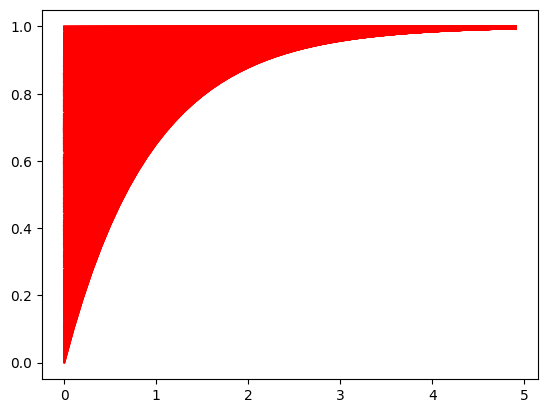

In [108]:
cluster1 = NeuralCluster(1000, 0.1)
cluster1.set_input(-10)
x0 = np.random.rand(cluster1.N)
#x0 = np.zeros(cluster1.N)
cluster1.compute_dynamics(x0, 5, 0.1)
plot_dynamics(cluster1, color='r')
cluster1.r.shape

cluster2 = NeuralCluster(1000, 0.1)

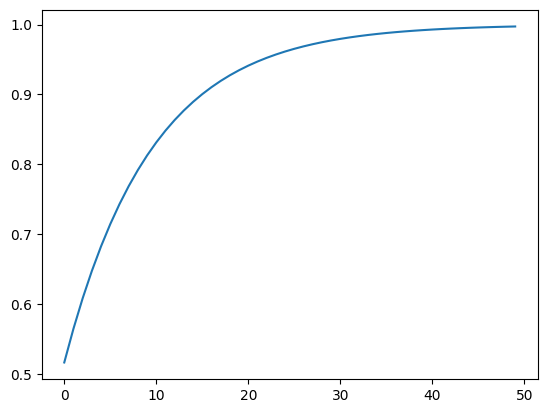

In [109]:
plt.plot(cluster1.r)

In [77]:
# A class to implement the whole network : two conencted cluseters, linked by inhibitory basket cells. 
# TO BE WRITTEN
class ConnectedClusters():
    def __init__(self, N, n_baskets):
        # Cluster 1
        self.cluster1 = NeuralCluster(N, 0.1)
        # Cluster 2
        self.cluster2 = NeuralCluster(N, 0.1)
        # Basket cell affectation array: to each neuron in cluster1/2 correspond one basket cell. Size 2xN.
        self.B_affect = np.random.randint(0, n_baskets, size=(2,N))
        # Hold the connectivity matrices from the clusters to the basket cells.
        # All cluster neurons have a weight 1 to the corresponding basket cell.
        # The basket cell should have a large negative weight to the cluster neurons.
        # WIP
        self.B_connect = []
        for i in range(n_baskets):
            W = np.ones(np.nonzero(self.B_affect == i)[0].shape[0])
            self.B_connect.append(W)
        # WIP
        # Must extract the corresponding neurons from the clusters to define the input of the basket cell at each dynamical step.
    

In [78]:
model = ConnectedClusters(1000, 5)